In [6]:
import numpy as np
import wildfire
from utils.functions import G
import matplotlib.pyplot as plt
from scipy.stats import qmc, norm
import random 
import pickle

In [ ]:


kap=0.1
eps = 0.3
upc = 3
alp = 0
q = 1
x_min, x_max = 0, 1
y_min, y_max = 0, 1
t_min, t_max = 0, 1
mu=1.25


def runSolver(physical_parameters):
    wildfire_ = wildfire.Fire(**physical_parameters)
    Nx=64   
    Ny = Nx
    Nt = 5 * Nx**2
    u0=lambda X, Y: np.exp(-((X-0.5)**2 + (Y-0.5)**2)/0.02) 
    b0 = lambda X, Y: np.ones_like(X)
    V=lambda x, y, t: (0*x, 0*y)
    t, X, Y, U, B = wildfire_.solvePDE(Nx, Ny, Nt, u0, b0, V, 'FD', 'RK4', last=True, acc=2, sparse=False)

    SRQ_betamax_num   = np.max(B)
    SRQ_umax_num   = np.max(U)

    print(f" SRQ_betamax_num is: {SRQ_betamax_num}")
    print(f" SRQ_umax_num is: {SRQ_umax_num}")

    print("done")
    return SRQ_umax_num



In [22]:

# Choosing an appropriate sigma value
sigmas = [0.08, 0.1, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5]
values=[]
for i in sigmas:
    print(f"Running for Sigma = {i}")
    physical_parameters1 = {    
        'kap': kap, # diffusion coefficient
        'eps': eps, # inverse of activation energy
        'upc': mu-i, # u phase change
        'q':q, # reaction heat
        'alp': alp, 
        'x_lim': (x_min, x_max), # x-axis domain 
        'y_lim': (y_min, y_max), # y-axis domain
        't_lim': (t_min, t_max), # time domain
        'components':(True, False, True) #diffusion, convection, reaction
    }
    physical_parameters2 = {    
        'kap': kap, # diffusion coefficient
        'eps': eps, # inverse of activation energy
        'upc': mu+i, # u phase change
        'q': q, # reaction heat
        'alp': alp, 
        'x_lim': (x_min, x_max), # x-axis domain 
        'y_lim': (y_min, y_max), # y-axis domain
        't_lim': (t_min, t_max), # time domain
        'components':(True, False, True) #diffusion, convection, reaction
    }
    srq_high_u, srq_high_b = runSolver(physical_parameters2)
    srq_low_u, srq_low_b = runSolver(physical_parameters1)

    print("U difference:", abs(srq_high_u - srq_low_u))
    print("B difference:", abs(srq_high_b - srq_low_b))


Running for Sigma = 0.08
 SRQ_betamax_num is: 2.0041607963483403
 SRQ_umax_num is: 3.637515159075004
done
 SRQ_betamax_num is: 1.9062012908763943
 SRQ_umax_num is: 4.0741174580476365
done
U difference: 0.4366022989726326
B difference: 0.09795950547194598
Running for Sigma = 0.1
 SRQ_betamax_num is: 2.0161558714232197
 SRQ_umax_num is: 3.579967927869562
done
 SRQ_betamax_num is: 1.8939616381777569
 SRQ_umax_num is: 4.125311159784646
done
U difference: 0.5453432319150839
B difference: 0.12219423324546286
Running for Sigma = 0.2
 SRQ_betamax_num is: 2.0740513563554552
 SRQ_umax_num is: 3.28431218229713
done
 SRQ_betamax_num is: 1.8335503786249359
 SRQ_umax_num is: 4.368268729865282
done
U difference: 1.0839565475681514
B difference: 0.24050097773051937
Running for Sigma = 0.25
 SRQ_betamax_num is: 2.1010894402995
 SRQ_umax_num is: 3.132279141026079
done
 SRQ_betamax_num is: 1.804106671991156
 SRQ_umax_num is: 4.481017473913166
done
U difference: 1.3487383328870872
B difference: 0.29698276

In [4]:

sigma=0.25
upcmin=mu-sigma
upcmax=mu+sigma
chi1=[0.55, 0.95, 1.0, 1.1, 1.5]
chi2=[0.1,0.4,0.6,0.75,0.8,0.9,0.91,0.97,1.3,1.6]
values=[]
for i in [upcmin, upcmax]:
    physical_parameters = {    
        'kap': kap, # diffusion coefficient
        'eps': eps, # inverse of activation energy
        'upc': i, # u phase change
        'q': q, # reaction heat
        'alp': alp, 
        'x_lim': (x_min, x_max), # x-axis domain 
        'y_lim': (y_min, y_max), # y-axis domain
        't_lim': (t_min, t_max), # time domain
        'components':(True, False, True) #diffusion, convection, reaction
    }
    values.append(runSolver(physical_parameters))
alpha=min(values)
beta=max(values)
expdata1=[alpha + (c*(beta-alpha)) for c in chi1]
expdata2=[alpha + (c*(beta-alpha)) for c in chi2]
print(expdata1)
print(expdata2)

 SRQ_betamax_num is: 1.804106671991156
 SRQ_umax_num is: 4.481017473913166
done
 SRQ_betamax_num is: 2.1010894402995
 SRQ_umax_num is: 3.132279141026079
done
[np.float64(3.874085224113977), np.float64(4.413580557268812), np.float64(4.481017473913166), np.float64(4.615891307201875), np.float64(5.15538664035671)]
[np.float64(3.2671529743147874), np.float64(3.6717744741809137), np.float64(3.941522140758331), np.float64(4.143832890691394), np.float64(4.211269807335748), np.float64(4.346143640624457), np.float64(4.3596310239533285), np.float64(4.440555323926553), np.float64(4.885638973779292), np.float64(5.290260473645418)]


In [ ]:
#Part 2 Validation metric computation

# Initialize the LHS sampler (d = dimensions)

mean = mu        
std = sigma
l_bounds=0
# Transform to Normal Distribution (mean=0, std=1)
sampler10 = qmc.LatinHypercube(d=1, seed=42)
sample10= sampler10.random(n=10)
sample10 = sample10.flatten()
sample10 = norm.ppf(sample10, loc=mean, scale=std)

sampler25 = qmc.LatinHypercube(d=1, seed=43)
sample25= sampler25.random(n=25)
sample25 = sample25.flatten()
sample25 = norm.ppf(sample25, loc=mean, scale=std)

sampler100 = qmc.LatinHypercube(d=1, seed=44)
sample100= sampler100.random(n=100)
sample100 = sample100.flatten()
sample100 = norm.ppf(sample100, loc=mean, scale=std)
sample100 = np.clip(sample100, 1e-6, None)
# print(np.sum(sample100 <= 0)) 

print(len(sample10), len(sample25), len(sample100))
print(np.min(sample10), np.min(sample25), np.min(sample100))

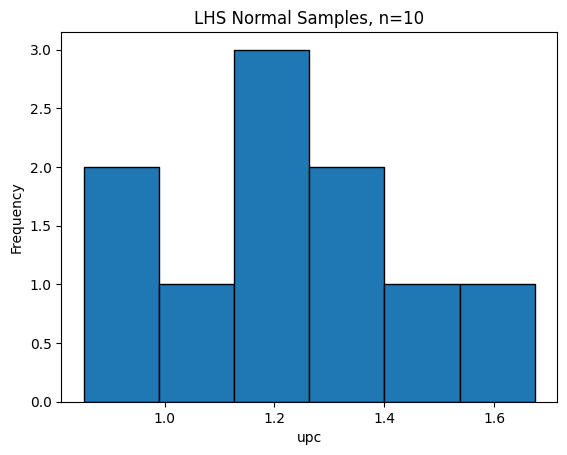

<Figure size 640x480 with 0 Axes>

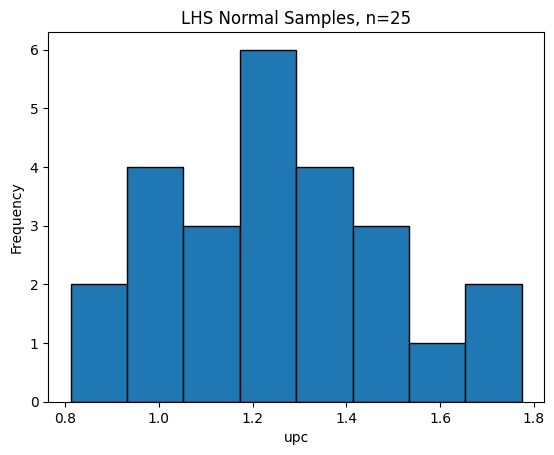

<Figure size 640x480 with 0 Axes>

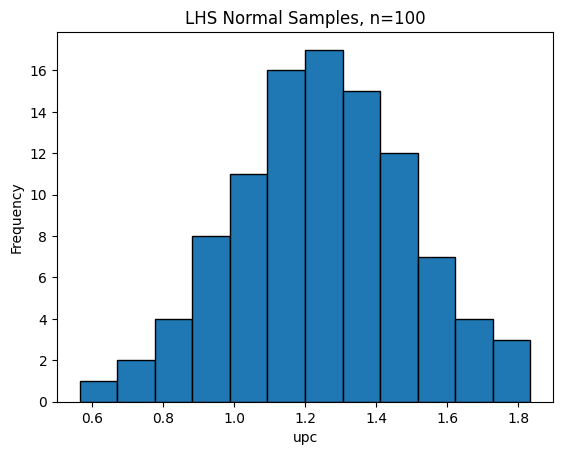

<Figure size 640x480 with 0 Axes>

In [33]:
plt.figure()
plt.hist(sample10, bins=6, edgecolor='black')
plt.title("LHS Normal Samples, n=10")
plt.xlabel("upc")
plt.ylabel("Frequency")
plt.show()
plt.savefig("output1.png")
plt.figure()
plt.hist(sample25, bins=8, edgecolor='black')
plt.title("LHS Normal Samples, n=25")
plt.xlabel("upc")
plt.ylabel("Frequency")
plt.show()
plt.savefig("output2.png")
plt.figure()
plt.hist(sample100, bins=12, edgecolor='black')
plt.title("LHS Normal Samples, n=100")
plt.xlabel("upc")
plt.ylabel("Frequency")
plt.show()
plt.savefig("output3.png")

In [34]:
SRQ10=[]
for i in range(0,10):
    physical_parameters = {    
        'kap': kap, # diffusion coefficient
        'eps': eps, # inverse of activation energy
        'upc': sample10[i], # u phase change
        'q': q, # reaction heat
        'alp': alp, 
        'x_lim': (x_min, x_max), # x-axis domain 
        'y_lim': (y_min, y_max), # y-axis domain
        't_lim': (t_min, t_max), # time domain
        'components':(True, False, True) #diffusion, convection, reaction
    }
    SRQ10.append(runSolver(physical_parameters))

 SRQ_betamax_num is: 2.0442408137782317
 SRQ_umax_num is: 3.4406452596429884
done
 SRQ_betamax_num is: 1.6941270208518273
 SRQ_umax_num is: 4.734748420588593
done
 SRQ_betamax_num is: 1.9220473310040032
 SRQ_umax_num is: 4.006949362494657
done
 SRQ_betamax_num is: 1.842781028413903
 SRQ_umax_num is: 4.33208300718136
done
 SRQ_betamax_num is: 1.912685503914758
 SRQ_umax_num is: 4.04678804261682
done
 SRQ_betamax_num is: 1.9563265789824518
 SRQ_umax_num is: 3.8572841111730343
done
 SRQ_betamax_num is: 1.7716186825081053
 SRQ_umax_num is: 4.560365722259665
done
 SRQ_betamax_num is: 2.0905357573954837
 SRQ_umax_num is: 3.192877330216609
done
 SRQ_betamax_num is: 2.0291744824285596
 SRQ_umax_num is: 3.516107133870455
done
 SRQ_betamax_num is: 2.178230619403267
 SRQ_umax_num is: 2.5891646421122037
done


In [35]:
SRQ25=[]
for i in range(0,25):
    physical_parameters = {    
        'kap': kap, # diffusion coefficient
        'eps': eps, # inverse of activation energy
        'upc': sample25[i], # u phase change
        'q': q, # reaction heat
        'alp': alp, 
        'x_lim': (x_min, x_max), # x-axis domain 
        'y_lim': (y_min, y_max), # y-axis domain
        't_lim': (t_min, t_max), # time domain
        'components':(True, False, True) #diffusion, convection, reaction
    }
    SRQ25.append(runSolver(physical_parameters))

 SRQ_betamax_num is: 1.7813131959402464
 SRQ_umax_num is: 4.5372233821321855
done
 SRQ_betamax_num is: 1.8828734924126318
 SRQ_umax_num is: 4.171054335170164
done
 SRQ_betamax_num is: 1.9627657829581984
 SRQ_umax_num is: 3.82845716742221
done
 SRQ_betamax_num is: 1.6795321956833797
 SRQ_umax_num is: 4.7649961069478985
done
 SRQ_betamax_num is: 1.8145240812370913
 SRQ_umax_num is: 4.441540834194163
done
 SRQ_betamax_num is: 1.9128566316831184
 SRQ_umax_num is: 4.04605859735553
done
 SRQ_betamax_num is: 1.832553299725959
 SRQ_umax_num is: 4.372126776563981
done
 SRQ_betamax_num is: 1.895981884958502
 SRQ_umax_num is: 4.116923587960555
done
 SRQ_betamax_num is: 2.0032410638265317
 SRQ_umax_num is: 3.641875455817277
done
 SRQ_betamax_num is: 2.2051470701456544
 SRQ_umax_num is: 2.269533849945658
done
 SRQ_betamax_num is: 1.9791937221199098
 SRQ_umax_num is: 3.753935836063918
done
 SRQ_betamax_num is: 2.12595040823419
 SRQ_umax_num is: 2.980434865352317
done
 SRQ_betamax_num is: 2.116605223

In [36]:
SRQ100=[]
for i in range(0,100):
    physical_parameters = {    
        'kap': kap, # diffusion coefficient
        'eps': eps, # inverse of activation energy
        'upc': sample100[i], # u phase change
        'q': q, # reaction heat
        'alp': alp, 
        'x_lim': (x_min, x_max), # x-axis domain 
        'y_lim': (y_min, y_max), # y-axis domain
        't_lim': (t_min, t_max), # time domain
        'components':(True, False, True) #diffusion, convection, reaction
    }
    SRQ100.append(runSolver(physical_parameters))

 SRQ_betamax_num is: 1.7564724992696528
 SRQ_umax_num is: 4.595995935742988
done
 SRQ_betamax_num is: 1.8510847960294268
 SRQ_umax_num is: 4.299322101709061
done
 SRQ_betamax_num is: 1.9924781423225038
 SRQ_umax_num is: 3.6924452273141726
done
 SRQ_betamax_num is: 2.2127399419041573
 SRQ_umax_num is: 2.075322107384667
done
 SRQ_betamax_num is: 1.8871869760098479
 SRQ_umax_num is: 4.153363996836711
done
 SRQ_betamax_num is: 1.9089991584110855
 SRQ_umax_num is: 4.062316294559102
done
 SRQ_betamax_num is: 2.1163132190126115
 SRQ_umax_num is: 3.0409592158790906
done
 SRQ_betamax_num is: 2.199546542672818
 SRQ_umax_num is: 2.3555496212646783
done
 SRQ_betamax_num is: 1.7610091325951929
 SRQ_umax_num is: 4.585412493463846
done
 SRQ_betamax_num is: 1.9955885403206577
 SRQ_umax_num is: 3.6779528857647477
done
 SRQ_betamax_num is: 1.816739928022391
 SRQ_umax_num is: 4.433090179789868
done
 SRQ_betamax_num is: 2.050047603108429
 SRQ_umax_num is: 3.410951851894238
done
 SRQ_betamax_num is: 2.0101

In [37]:
import pickle

with open("SRQ10.pkl", "wb") as f:
    pickle.dump(SRQ10, f)

with open("SRQ25.pkl", "wb") as f:
    pickle.dump(SRQ25, f)

with open("SRQ100.pkl", "wb") as f:
    pickle.dump(SRQ100, f)

In [7]:
with open("SRQ10.pkl", "rb") as f:
    SRQ10 = pickle.load(f)

with open("SRQ25.pkl", "rb") as f:
    SRQ25 = pickle.load(f)

with open("SRQ100.pkl", "rb") as f:
    SRQ100 = pickle.load(f)

In [8]:
SRQ10

[np.float64(3.4406452596429884),
 np.float64(4.734748420588593),
 np.float64(4.006949362494657),
 np.float64(4.33208300718136),
 np.float64(4.04678804261682),
 np.float64(3.8572841111730343),
 np.float64(4.560365722259665),
 np.float64(3.192877330216609),
 np.float64(3.516107133870455),
 np.float64(2.5891646421122037)]

In [ ]:
plt.scatter(sample10, SRQ10)
plt.xlabel("upc")
plt.ylabel("SRQ")
plt.title("SRQ vs upc")
plt.show()
plt.savefig("output4.png")
plt.scatter(sample25, SRQ25)
plt.xlabel("upc")
plt.ylabel("SRQ")
plt.title("SRQ vs upc")
plt.show()
plt.savefig("output5.png")

plt.scatter(sample100, SRQ100)
plt.xlabel("upc")
plt.ylabel("SRQ")
plt.title("SRQ vs upc")
plt.show()
plt.savefig("output6.png")

In [23]:
SRQ10.sort()
SRQ25.sort()
SRQ100.sort()
expdata1.sort()
expdata2.sort()

In [12]:
cum_prob_10=[i/10 for i in range(0, 10)]
cum_prob_25=[i/25 for i in range(0, 25)]
cum_prob_100=[i/100 for i in range(0, 100)]

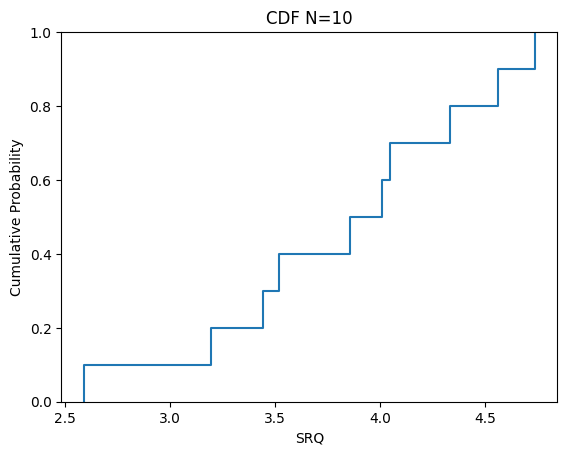

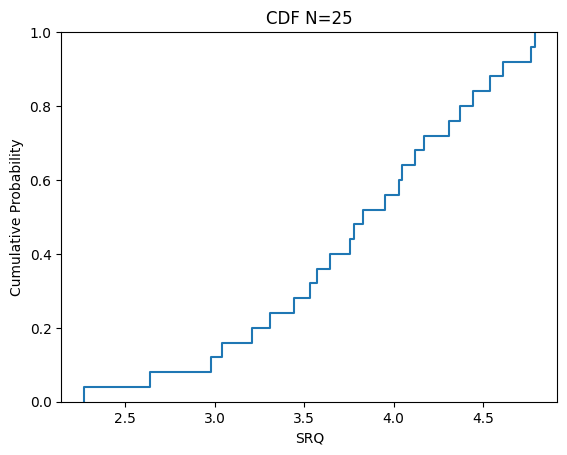

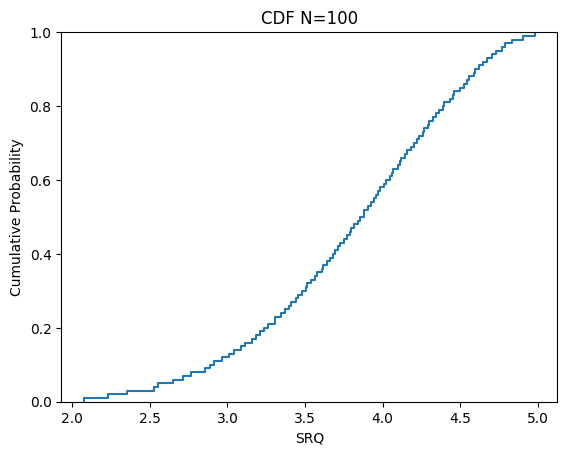

In [16]:
plt.ecdf(SRQ10)
plt.xlabel('SRQ')
plt.ylabel('Cumulative Probability')
plt.title("CDF N=10")
plt.show()

plt.ecdf(SRQ25)
plt.xlabel('SRQ')
plt.ylabel('Cumulative Probability')
plt.title("CDF N=25")
plt.show()

plt.ecdf(SRQ100)
plt.xlabel('SRQ')
plt.ylabel('Cumulative Probability')
plt.title("CDF N=100")
plt.show()

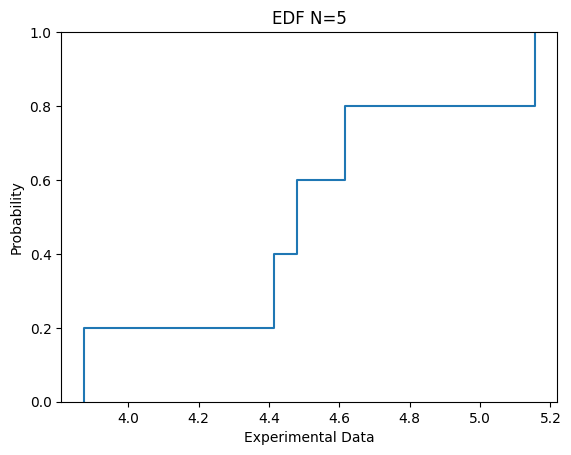

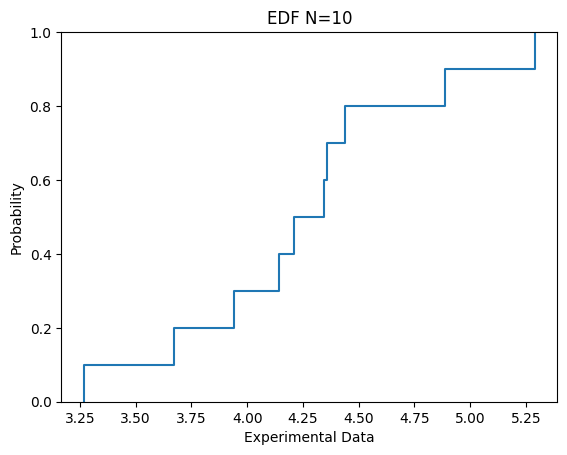

In [17]:
plt.ecdf(expdata1)
plt.xlabel('Experimental Data')
plt.ylabel('Probability')
plt.title("EDF N=5")
plt.show()

plt.ecdf(expdata2)
plt.xlabel('Experimental Data')
plt.ylabel('Probability')
plt.title("EDF N=10")
plt.show()


In [77]:
expdata1

[np.float64(3.874085224113977),
 np.float64(4.413580557268812),
 np.float64(4.481017473913166),
 np.float64(4.615891307201875),
 np.float64(5.15538664035671)]

Exp N=5, Sim N=10: d+=0.0865, d-=0.7915, MAVM=max=0.7915


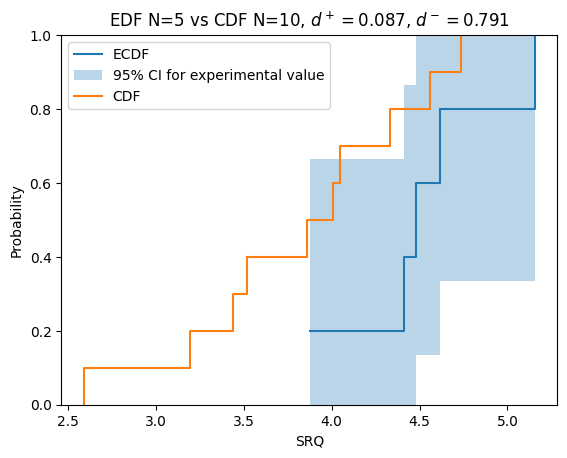

Exp N=5, Sim N=25: d+=0.0881, d-=0.7899, MAVM=max=0.7899


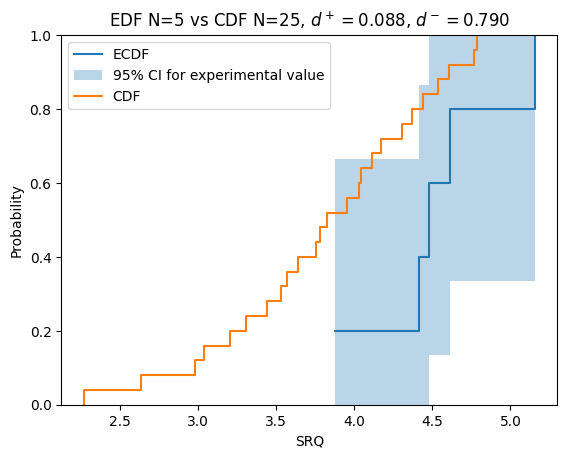

Exp N=5, Sim N=100: d+=0.1040, d-=0.7740, MAVM=max=0.7740


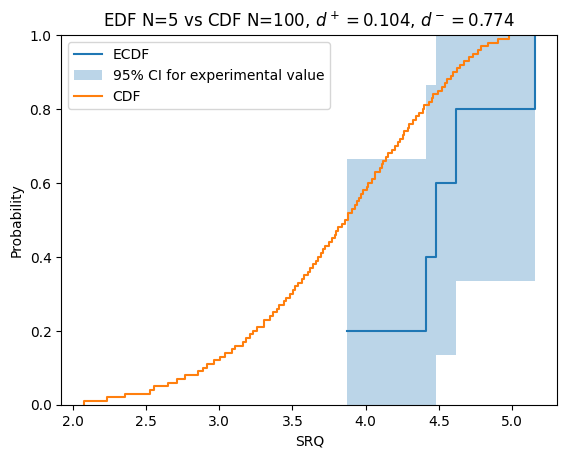

Exp N=10, Sim N=10: d+=0.2370, d-=0.9845, MAVM=max=0.9845


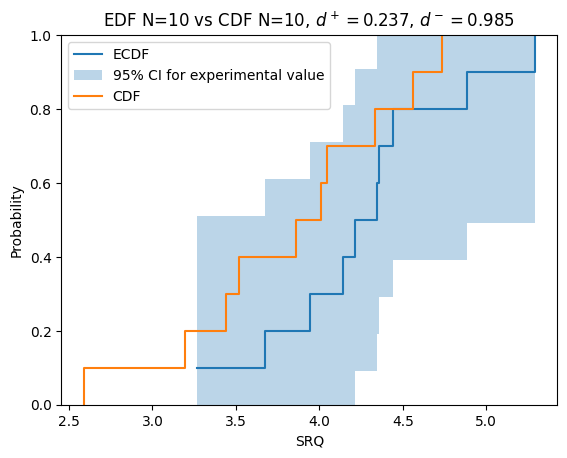

Exp N=10, Sim N=25: d+=0.2620, d-=0.9595, MAVM=max=0.9595


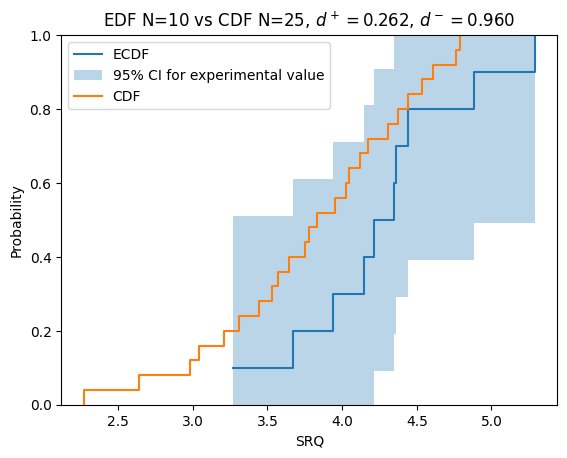

Exp N=10, Sim N=100: d+=0.2876, d-=0.9339, MAVM=max=0.9339


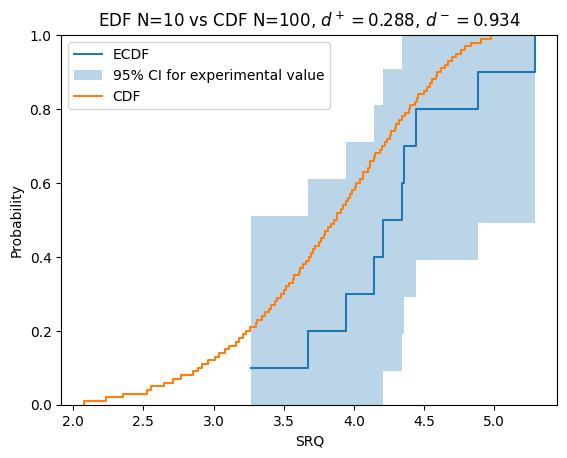

In [113]:
import scipy.stats as st
ki=0
for k in [expdata1, expdata2]:
    ki+=1
    s = np.std(k, ddof=1)  
    t_val = 2.776 if len(k)==1 else 2.262
    x_exp = np.sort(k)
    S_n = np.arange(1, len(k)+1) / len(k) 
    
    # CI 
    upper = S_n + t_val * s / np.sqrt(len(k))
    lower = S_n - t_val * s / np.sqrt(len(k))
    upper = np.minimum(upper, 1.0)
    lower = np.maximum(lower, 0.0)
    for i in [SRQ10, SRQ25, SRQ100]:
        x_sim = np.sort(i)
        F = np.arange(1, len(i)+1) / len(i)  
        F_interp = np.interp(x_exp, x_sim, F)
        
        d_plus = np.trapezoid(np.maximum(upper - F_interp, 0), x_exp)
        d_minus = np.trapezoid(np.maximum(F_interp - lower, 0), x_exp)
        
        print(f"Exp N={len(k)}, Sim N={len(i)}: d+={d_plus:.4f}, d-={d_minus:.4f}, MAVM=max={max(d_plus,d_minus):.4f}")

        plt.step(x_exp, S_n, label='ECDF', where='post')
        plt.fill_between(x_exp, lower, upper, alpha=0.3, step='post', label='95% CI for experimental value')
        plt.ecdf(i, label="CDF")
        plt.xlabel('SRQ')
        plt.ylabel('Probability')
        plt.title(
            rf"EDF N={len(k)} vs CDF N={len(i)}, "
            rf"$d^+={d_plus:.3f}$, $d^-={d_minus:.3f}$"
        )
        plt.legend()
        plt.savefig(f"plot_exp{ki}_{len(i)}.png")
        plt.show()
